# Bin-integrated response function $\mathcal{R}_{\left[E_i^\prime, E_{i+1}^\prime\right]}(E_\nu)$

Plots the bin-integrated response functions exported by
`{1eV,5eV}/src/05b_curlyR_export.wl` (2000 $E_\nu$ points, units
cm$^2$/(MeV kg)) from `{1eV,5eV}/output/curlyR_table.csv`.

Curves are coloured by bin width: 2 eV (black), 5 eV, 10 eV and 39 eV
(Okabe–Ito colours), with one legend entry per width class.
The 5 eV threshold uses the same bins as 1 eV except the first two
(1–3 and 3–5 eV), which fall below threshold.

Style follows `plot_band_comparison` (physrev style sheet, log $E_\nu$ axis,
large labels, frameless legend). Run this notebook from the `Mathematica/` folder.

In [8]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator

_style = os.path.join('..', '1eV', 'physrev.mplstyle')
if os.path.exists(_style):
    plt.style.use(_style)

NORM = 1e-16

# one (colour, linestyle, linewidth) per bin-width class; Okabe–Ito palette
WIDTH_STYLE = {
    2:  dict(color='black',   ls='solid',  lw=1.4, alpha=0.6),
    5:  dict(color='#0072B2', ls='solid',  lw=2.8),
    10: dict(color='#D55E00', ls='dashed', lw=2.8),
    39: dict(color='#009E73', ls='dotted', lw=3.2),
}

def _bin_width(col):
    """Parse 'NN-MM eV' and return width in eV."""
    m = re.match(r'"?(\d+)-(\d+)', col)
    if m:
        return int(m.group(2)) - int(m.group(1))
    return None

def plot_curlyR(thr, xmin):
    df = pd.read_csv(os.path.join(thr, 'output', 'curlyR_table.csv'))
    ev = df['Ev_MeV'].values
    bins = [c for c in df.columns if c != 'Ev_MeV']

    plt.figure(figsize=(8, 6))
    seen = set()
    for col in bins:
        w = _bin_width(col)
        st = WIDTH_STYLE.get(w)
        if st is None:
            raise ValueError(f'unexpected bin width {w} eV for column {col!r}')
        lbl = f'Bin width {w} eV' if w not in seen else None
        seen.add(w)
        plt.plot(ev, df[col].values / NORM, label=lbl, **st)

    plt.xscale('log')
    plt.xlim(xmin, 10)
    plt.ylim(0, None)
    plt.xlabel(r"$E_\nu$ [MeV]", fontsize=30)
    plt.ylabel(r"$\mathcal{R}_i$ [$10^{-16}$ cm$^2$/(MeV kg)]", fontsize=30)
    plt.gca().xaxis.set_minor_locator(
        LogLocator(base=10.0, subs=np.arange(1.0, 10) * 0.1, numticks=20))
    plt.tick_params(axis='both', which='major', labelsize=23)
    plt.tick_params(axis='both', which='minor', labelsize=23)
    plt.legend(loc='upper left', frameon=False,
               prop={'family': 'DejaVu Sans', 'size': 16.0},
               title=r"$E'$ bin", title_fontsize=22)
    plt.tight_layout()
    out = os.path.join(thr, 'output', 'curlyR_' + thr + '.pdf')
    plt.savefig(out, bbox_inches='tight')
    print('saved', out)
    plt.show()

saved 1eV/output/curlyR_1eV.pdf


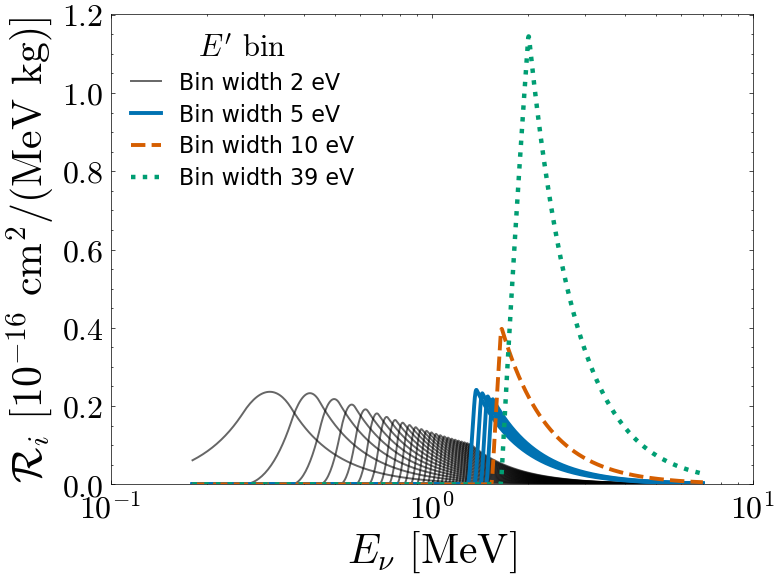

saved 5eV/output/curlyR_5eV.pdf


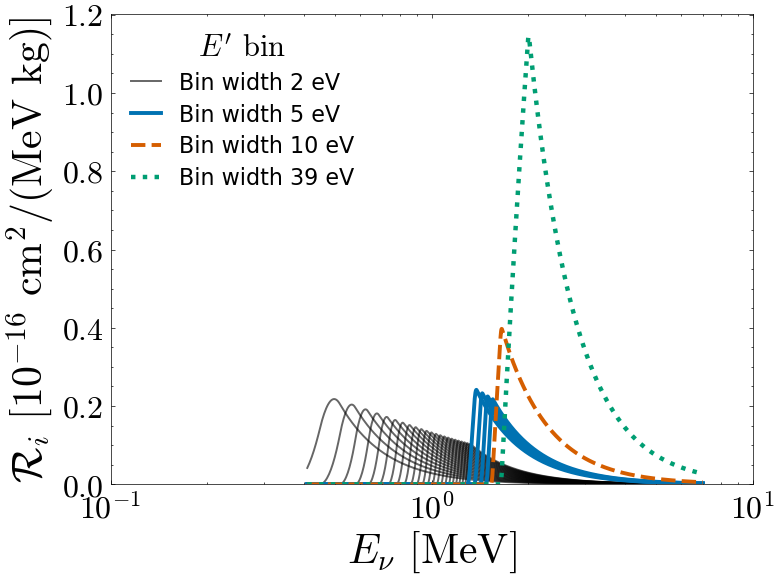

In [9]:
plot_curlyR('1eV', 0.1)
plot_curlyR('5eV', 0.1)